In [27]:
import numpy as np
import pandas as pd
import globals.path as pth
import globals.imaging as im
import matplotlib.pyplot as plt
import nitools as nt
import nitools.spm as spm
from nitools.spm import spm_hrf
import nibabel as nb
from util.util import calc_R2
import os
from imaging.hrf import Optimise_HRF

plt.style.use('default')

In [28]:
sn = 102
H = 'L'
roi = 'M1'
glm = 1
HRF = Optimise_HRF(sn=sn, glm=glm, H=H, roi=roi)
#print(HRF.P)

['5.2892222804879365', '17.702425873995796', '1.428127360262121', '0.6000000000000001', '4.720562011816162', '0.0', '32.0']
R2=0.04907263857715527


[]

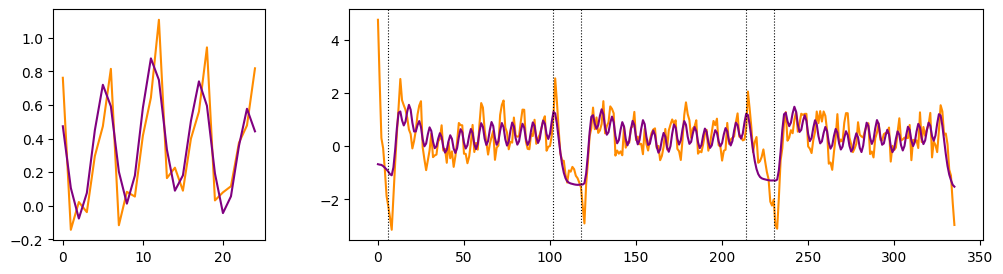

In [29]:
P = HRF.df[HRF.df.sn==sn].reset_index()['P'][0].split(',')
print(P)
#P = [8, 15, 3, 3, 2, 0, 32]
y_hat, y_adj, y_cut_hat, y_cut_adj = HRF.manual(P)
intervals = [(0,12), (102,124), (214, 236)]
# for start, end in intervals:
#     y_adj[start:end] = np.nan
#     y_hat[start:end] = np.nan
R2 = calc_R2(y_adj, y_hat)
print(f'R2={R2}')
y_adj_bl = np.array(np.split(y_adj, y_adj.shape[0] // im.nTR, axis=0))
y_hat_bl = np.array(np.split(y_hat, y_hat.shape[0] // im.nTR, axis=0))

fig, axs = plt.subplots(1, 2, gridspec_kw={'width_ratios': (1, 3)}, figsize=(12, 3), )

axs[0].plot(y_cut_adj.mean(axis=(0, -1)), color='darkorange')
axs[0].plot(y_cut_hat.mean(axis=(0, -1)), color='purple')
axs[1].plot(y_adj_bl.mean(axis=(0, -1)), color='darkorange')
axs[1].plot(y_hat_bl.mean(axis=(0, -1)), color='purple')
axs[1].axvline(6, ls=':', lw=.8, color='k')
axs[1].axvline(102, ls=':', lw=.8, color='k')
axs[1].axvline(118, ls=':', lw=.8, color='k')
axs[1].axvline(214, ls=':', lw=.8, color='k')
axs[1].axvline(230, ls=':', lw=.8, color='k')

plt.plot()